# Estudio del Entrenamiento de Gaussianas

Este notebook permite ejecutar el entrenamiento de 3D Gaussian Splatting de forma interactiva, visualizando los resultados y analizando las métricas de densidad.

In [1]:
import torch
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm
from opensplat3d.utils.vis_utils import pca, enhance_image
import numpy as np
#import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from opensplat3d.utils.train_utils import setup_training, train_cameras
from opensplat3d.scene import Scene
from opensplat3d.gaussian_model import create_from_pcd
from opensplat3d.gaussian_optimizer import GaussianOptimizer
from opensplat3d.gaussian_renderer import render
from opensplat3d.losses import l1_loss, ssim, instance_2d_loss, get_erank_loss, get_thinness_loss
from opensplat3d.data import load_scene_info
from opensplat3d.utils.train_utils import train_cameras

device = torch.device("cuda:0")
device2 = torch.device("cuda:1")

Using fused SSIM


### 1. Configuración y Carga de Datos
Asegúrate de apuntar a un archivo de configuración válido y establecer el path del modelo.

In [2]:
class Args:
    config = "/home/jsm15/opensplat3d/configs/lerf_vlm.yaml"
    overrides = [
        "model.source_path=/home/jsm15/datasets/Replica/room0",
        "model.model_path=output/training_study_replica" 
    ]
    wandb = None
    checkpoint = None
    
args = Args()
config = setup_training(args)

model_params = config.model
opt_params = config.opt
pipe_params = config.pipe

scene_info = load_scene_info(model_params)
scene = Scene(scene_info, model_params.resolution, device)
viewpoint_cams = train_cameras(scene)

gaussians = create_from_pcd(
    scene_info.point_cloud,
    model_params.sh_degree,
    device,
    model_params.mask_subdir is not None,
    model_params.mask_dim,
    opt_params.feature_init,
    opt_params.static_xyz,
)

optimizer = GaussianOptimizer(
    gaussians,
    opt_params,
    model_params.sh_degree,
    scene.cameras_extent,
    opt_params.static_xyz,
    device,
)

background = torch.tensor([0, 0, 0], dtype=torch.float32, device=device)

Found traj.txt file, assuming Replica data set!


Loading training cameras:   0%|          | 0/437 [00:00<?, ?it/s]

Loading testing cameras:   0%|          | 0/63 [00:00<?, ?it/s]

Train: 437 | Test: 63
Loading Training Cameras


  0%|          | 0/437 [00:00<?, ?it/s]

Loading Test Cameras


  0%|          | 0/63 [00:00<?, ?it/s]

Number of points at initialisation: 100000


### 2. Bucle de Entrenamiento Interactivo
En esta celda puedes ejecutar un número determinado de iteraciones y ver los resultados.

In [ ]:
import torch
import numpy as np
from opensplat3d.utils.general_utils import build_rotation
from opensplat3d.gaussian_renderer import render

def get_gt_normals(viewpoint_cam, device):
    """Calcula el mapa de normales GT (World Space) desde la profundidad."""
    depth = viewpoint_cam.original_depth.to(device)
    h, w = depth.shape
    fx = w / (2 * np.tan(viewpoint_cam.fovX / 2))
    fy = h / (2 * np.tan(viewpoint_cam.fovY / 2))
    cx, cy = w / 2, h / 2

    i, j = torch.meshgrid(torch.linspace(0, w-1, w, device=device), 
                          torch.linspace(0, h-1, h, device=device), indexing='xy')
    
    points = torch.stack([(i - cx) * depth / fx, (j - cy) * depth / fy, depth], dim=-1)
    
    dy = torch.zeros_like(points)
    dx = torch.zeros_like(points)
    dy[1:-1, :, :] = points[2:, :, :] - points[:-2, :, :]
    dx[:, 1:-1, :] = points[:, 2:, :] - points[:, :-2, :]

    normals = torch.nn.functional.normalize(torch.cross(dx, dy, dim=-1), dim=-1)
    
    # Pasar a World Space
    R_c2w = viewpoint_cam.R.to(device)
    normals_world = (R_c2w @ normals.view(-1, 3).T).T.view(h, w, 3)
    return normals_world.permute(2, 0, 1) # (3, H, W)

def render_normals(viewpoint_cam, gaussians, pipe, config, device):
    """Renderiza el mapa de normales actual (World Space)."""
    R = build_rotation(gaussians._rotation)
    scales = gaussians.get_scaling
    min_scale_idx = torch.argmin(scales, dim=1)
    
    normals = torch.gather(R, 2, min_scale_idx.view(-1, 1, 1).expand(-1, 3, 1)).squeeze(-1)
    normal_colors = normals * 0.5 + 0.5 # Mapeo a [0, 1] para el renderizador
    
    bg = torch.tensor([0, 0, 0], dtype=torch.float32, device=device)
    res = render(viewpoint_cam, gaussians, pipe, bg, config.model.sh_degree,
                 config.model.sh_degree, override_color=normal_colors)
    
    # Devolver mapeado de vuelta a [-1, 1] para el cálculo del Loss
    return res.render * 2.0 - 1.0


In [ ]:
def normal_consistency_loss(n_render, n_gt):
    """
    Calcula la pérdida de normales basada en similitud de coseno.
    n_render: (3, H, W) en rango [-1, 1]
    n_gt: (3, H, W) en rango [-1, 1]
    """
    # Producto escalar entre vectores normales (Cosine Similarity)
    # 1.0 significa que apuntan al mismo sitio, -1.0 al contrario.
    cos_sim = (n_render * n_gt).sum(dim=0)
    
    # Queremos que la similitud sea 1.0 (o -1.0 ya que la normal de un 'disco' es ambigua)
    # Por eso usamos el valor absoluto de la similitud
    loss = 1.0 - torch.abs(cos_sim)
    
    return loss.mean()


In [ ]:
iterations_to_run = 10000
display_interval = 10

losses = []
gaussian_counts = []

start_iter = 1
progress_bar = tqdm(range(opt_params.iterations), desc="Training")
for iteration in progress_bar:
    optimizer.update_learning_rate(iteration)
    
    if iteration % 1000 == 0:
        optimizer.oneup_sh_degree()
        
    viewpoint_cam = next(viewpoint_cams)

    has_depth = hasattr(viewpoint_cam, "original_depth") and viewpoint_cam.original_depth is not None
    render_depth = has_depth and opt_params.lambda_depth > 0
    
    render_pkg = render(
        viewpoint_cam,
        gaussians,
        pipe_params,
        background,
        model_params.sh_degree,
        optimizer.active_sh_degree,
        render_color=True,
        render_depth=render_depth
    )
    
    image = render_pkg.render
    features = render_pkg.features
    variance = render_pkg.variance
    depth = render_pkg.depth

    image, viewspace_point_tensor, visibility_filter, radii = (
        render_pkg.render,
        render_pkg.viewspace_points,
        render_pkg.visibility_filter,
        render_pkg.radii,
    )

    mask_dim = config.model.mask_dim
    gt_image = viewpoint_cam.original_image.to(device)

    loss = torch.tensor(0.0, device=device)

    Ll1 = l1_loss(render_pkg.render, gt_image)
    photometric_loss = (1.0 - config.opt.lambda_dssim) * Ll1 + \
                   config.opt.lambda_dssim * (1.0 - ssim(render_pkg.render, gt_image))
    
    loss += config.opt.photo_lambda * photometric_loss

    depth_loss = None
    if render_depth and depth is not None and has_depth:
        gt_depth = viewpoint_cam.original_depth.to(device)
        depth_loss = l1_loss(depth, gt_depth)

        loss += opt_params.lambda_depth * depth_loss

    lambda_normal = 0.5

    normals = render_normals(viewpoint_cam, gaussians, pipe_params, config, device)
    normals_gt = get_gt_normals(viewpoint_cam, device)
    loss_norm = normal_consistency_loss(normals, normals_gt)
    loss += lambda_normal * loss_norm

    """
    if opt.normal_loss:
            rendered_normal = render_pkg['render_normal']
            if viewpoint_cam.normal is not None:
                normal_gt = viewpoint_cam.normal.cuda()
                if viewpoint_cam.sky_mask is not None:
                    filter_mask = viewpoint_cam.sky_mask.to(normal_gt.device).to(torch.bool)
                    normal_gt[~(filter_mask.unsqueeze(0).repeat(3, 1, 1))] = -10
                filter_mask = (normal_gt != -10)[0, :, :].to(torch.bool)

                l1_normal = torch.abs(rendered_normal - normal_gt).sum(dim=0)[filter_mask].mean()
                cos_normal = (1. - torch.sum(rendered_normal * normal_gt, dim = 0))[filter_mask].mean()
                loss += opt.lambda_l1_normal * l1_normal + opt.lambda_cos_normal * cos_normal
    """

    if variance is not None and config.opt.var_lambda > 0:
        var_loss = variance[:mask_dim].pow(2).mean()
        loss += config.opt.var_lambda * var_loss

    if viewpoint_cam.masks is not None and features is not None:
        if iteration % config.opt.inst2d_interval == 0:
            gt_masks = viewpoint_cam.masks.to(device)
            inst2d_loss = instance_2d_loss(
                features[:mask_dim],
                gt_masks,
                mask_dim,
                config.opt.inst2d_sample_size,
                config.opt.inst2d_gamma,
                config.opt.inst2d_weights,
                config.opt.inst2d_normalize,
            )
            loss += config.opt.inst2d_lambda * inst2d_loss["total"]

    
    current_scaling = gaussians.get_scaling
    
    warmup_weight = max(0.0, min(1.0, 1 / max(iteration, 1)))

    erank_loss = get_erank_loss(gaussians.get_scaling)
    thin_loss = get_thinness_loss(gaussians.get_scaling)
    
    if warmup_weight > 0:
        loss += warmup_weight * opt_params.lambda_erank * erank_loss
        loss += warmup_weight * opt_params.lambda_thin * thin_loss
    
    optimizer.optimizer.zero_grad(set_to_none=True)
    loss.backward()
    
    # Track statistics for Semantic Pruning
    optimizer.add_importance_stats()
    
    with torch.no_grad():
        losses.append(loss.item())
        optimizer.add_stats(viewspace_point_tensor, visibility_filter, radii)
        
        if iteration > opt_params.densify_from_iter and iteration % opt_params.densification_interval == 0:
            optimizer.densify_and_prune(opt_params.densify_grad_threshold, 0.005, scene.cameras_extent, None)
            
            # Semantic Pruning FeatureSLAM
            if opt_params.semantic_pruning_interval > 0 and iteration % opt_params.semantic_pruning_interval == 0:
                optimizer.semantic_pruning(opt_params.semantic_pruning_percentile)
                # Reset tracking after pruning
                optimizer.importance_accum.fill_(0)
                optimizer.denom.fill_(0)
                
        optimizer.optimizer.step()
        
    progress_bar.set_postfix({
        "L1": f"{Ll1.item():.4f}",
        "Pts": f"{gaussians.get_xyz.shape[0]}",
        "eRank": f"{erank_loss.item():.3f}",
        "depth": f"{depth_loss:.4e}"
    })
            
    losses.append(loss.item())
    gaussian_counts.append(gaussians.num_points)
    
    if iteration % display_interval == 0:
        clear_output(wait=True)
        plt.figure(figsize=(18, 10))
        
        # 1. Output RGB
        plt.subplot(3, 3, 1)
        plt.imshow(image.detach().permute(1, 2, 0).cpu().clamp(0, 1))
        plt.title(f"Render Iter {iteration}")
        plt.axis('off')
        
        # 2. GT RGB
        plt.subplot(3, 3, 2)
        plt.imshow(gt_image.permute(1, 2, 0).cpu().squeeze())
        plt.title("Ground Truth RGB")
        plt.axis('off')


        plt.subplot(3, 3, 3)
        plt.imshow(depth.detach().cpu(), cmap='plasma', vmin=0, vmax=8)
        plt.title(f"Depth Render Iter {iteration}")
        plt.axis('off')


        plt.subplot(3, 3, 4)
        plt.imshow(gt_depth.cpu(), cmap='plasma', vmin=0, vmax=8)
        plt.title("Ground Truth Depth")
        plt.axis('off')
        
        # 3. Ground Truth SAM Mask
        plt.subplot(3, 3, 5)
        # Colorize the integer mask values randomly or with colormap
        mask_np = gt_masks.cpu().numpy()
        plt.imshow(mask_np % 20, cmap='tab20', interpolation='nearest')
        plt.title("GT SAM Mask")
        plt.axis('off')

        # 4. Rendered Features (PCA)
        plt.subplot(3, 3, 6)
        if features is not None:
            # We take only the active mask dimensions (e.g., 8)
            mask_dim = model_params.mask_dim
            feats_to_plot = features[:mask_dim].permute(1, 2, 0).cpu().detach().numpy()
            H, W, C = feats_to_plot.shape
            
            # Compress to RGB using PCA exactly like Demo does
            pca_feats = pca(feats_to_plot.reshape(-1, C), 3, normalize=True).reshape(H, W, 3)
            pca_feats = (pca_feats * 255).astype(np.uint8)
            pca_feats = enhance_image(pca_feats)
            plt.imshow(pca_feats)
        plt.title("Rendered Semantics (PCA)")
        plt.axis('off')

        plt.subplot(3, 3, 7)
        normals_vis = (normals * 0.5 + 0.5).clamp(0, 1)
        plt.imshow(normals_vis.detach().permute(1, 2, 0).cpu().numpy())
        plt.title("Mapa de Normales (World Space)")
        plt.axis('off')

        plt.subplot(3, 3, 8)
        plt.imshow((normals_gt.permute(1, 2, 0).cpu() * 0.5 + 0.5).clamp(0, 1))
        plt.title("Ground Truth Normals (desde Depth)")
        plt.axis('off')
        
        # 5. L1 Loss
        plt.subplot(3, 3, 9)
        plt.plot(losses)
        plt.title("L1 Loss")
        plt.yscale('log')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Iteration {iteration} | Loss: {loss.item():.6f} | Gaussians: {gaussians.num_points} | Depth: {depth_loss:.4e} | w: {warmup_weight:.4e}")

start_iter += iterations_to_run

In [ ]:
from opensplat3d.gaussian_model import save_gaussians

# Guardamos el estado final (usando la iteración actual como nombre)
save_gaussians(gaussians, Path("output/training_study"), iteration)

print(f"Modelo guardado en output/training_study. Listo para ejecutar demo.py")

In [ ]:
from opensplat3d.utils.general_utils import build_rotation

def renderizar_normales(viewpoint_cam, gaussians, config, device):
    """
    Calcula y renderiza las normales de las gaussianas (eje de menor escala).
    """
    # 1. Construir las matrices de rotación a partir de los cuaterniones
    # R tiene forma (N, 3, 3) donde cada columna es un eje local
    R = build_rotation(gaussians._rotation)
    
    # 2. Identificar el eje más corto (la "normal")
    scales = gaussians.get_scaling
    min_scale_idx = torch.argmin(scales, dim=1) # Índice del eje con menor escala
    
    # Extraer el vector correspondiente de la matriz R
    # (Usamos gather para hacerlo de forma eficiente en GPU)
    normals = torch.gather(R, 2, min_scale_idx.view(-1, 1, 1).expand(-1, 3, 1)).squeeze(-1)
    
    # 3. Mapear las normales de [-1, 1] a [0, 1] para que el renderizador las acepte como colores
    # Las normales suelen visualizarse como (R, G, B) = (X, Y, Z)
    normal_colors = normals * 0.5 + 0.5
    
    # 4. Renderizar usando las normales como 'override_color'
    # Usamos fondo negro para que no interfiera
    background = torch.tensor([0, 0, 0], dtype=torch.float32, device=device)
    
    render_pkg = render(
        viewpoint_cam,
        gaussians,
        config.pipe,
        background,
        config.model.sh_degree,
        config.model.sh_degree,
        override_color=normal_colors # Forzamos que use nuestros colores de normales
    )
    
    return render_pkg.render

# --- Ejemplo de uso en el notebook ---
normal_map = renderizar_normales(next(viewpoint_cams), gaussians, config, device)

plt.imshow(normal_map.detach().permute(1, 2, 0).cpu().clamp(0, 1))
plt.title("Mapa de Normales (World Space)")
plt.show()


In [ ]:
def calcular_normales_gt(viewpoint_cam, device):
    """
    Calcula el mapa de normales Ground Truth a partir del mapa de profundidad.
    """
    depth = viewpoint_cam.original_depth.to(device) # (H, W)
    if depth is None:
        print("⚠️ Esta cámara no tiene mapa de profundidad GT.")
        return None

    h, w = depth.shape
    fx = w / (2 * np.tan(viewpoint_cam.fovX / 2))
    fy = h / (2 * np.tan(viewpoint_cam.fovY / 2))
    cx, cy = w / 2, h / 2

    # 1. Reconstruir puntos 3D en el espacio de la cámara
    i, j = torch.meshgrid(torch.linspace(0, w-1, w, device=device), 
                          torch.linspace(0, h-1, h, device=device), indexing='xy')
    
    z = depth
    x = (i - cx) * z / fx
    y = (j - cy) * z / fy
    points = torch.stack([x, y, z], dim=-1) # (H, W, 3)

    # 2. Calcular gradientes espaciales (vectores tangentes)
    # Diferencias finitas para obtener los vectores que definen el plano del píxel
    dy = torch.zeros_like(points)
    dx = torch.zeros_like(points)
    dy[1:-1, :, :] = points[2:, :, :] - points[:-2, :, :]
    dx[:, 1:-1, :] = points[:, 2:, :] - points[:, :-2, :]

    # 3. El producto vectorial de los gradientes nos da la normal
    # Nota: El orden (dx x dy) define si la normal mira hacia la cámara o hacia afuera
    normals = torch.cross(dx, dy, dim=-1)
    normals = torch.nn.functional.normalize(normals, dim=-1)

    # 4. Convertir normales de espacio de Cámara a espacio de Mundo (opcional)
    # Para comparar con el render que hicimos antes (que estaba en World Space)
    # Necesitamos la matriz de rotación de la cámara (Camera-to-World)
    R_c2w = viewpoint_cam.R.to(device) # R de la cámara
    h, w, _ = normals.shape
    normals_world = (R_c2w @ normals.view(-1, 3).T).T.view(h, w, 3)

    return normals_world.permute(2, 0, 1) # Retornar como (3, H, W)

# --- Uso en el notebook ---
gt_normal_map = calcular_normales_gt(next(viewpoint_cams), device)
plt.imshow(gt_normal_map.permute(1, 2, 0).cpu() * 0.5 + 0.5)
plt.title("Ground Truth Normals (desde Depth)")
plt.show()


### 3. Análisis de Puntos
Visualiza cómo ha evolucionado el número de Gaussianas durante el entrenamiento.

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(gaussian_counts)
plt.title("Evolución del número de Gaussianas")
plt.xlabel("Iteración")
plt.ylabel("Num Gaussianas")
plt.grid(True)
plt.show()

In [ ]:
from opensplat3d.gaussian_model import create_from_ply
from opensplat3d.utils.metric_utils import psnr
from opensplat3d.gaussian_renderer import render

def calcular_psnr_modelo(ply_path, scene, config, device):
    """
    Carga un modelo (.ply) y calcula el PSNR medio usando las cámaras de test.
    """
    
    gaussians = create_from_ply(
        Path(ply_path),
        config.model.sh_degree,
        device,
        feature_dim=config.model.mask_dim
    )
    
    
    bg_color = [1, 1, 1] if config.model.white_background else [0, 0, 0]
    background = torch.tensor(bg_color, dtype=torch.float32, device=device)
    
    
    test_cameras = scene.get_train_cameras()
    if not test_cameras:
        print("No se encontraron cámaras de test en la escena.")
        return None
        
    psnr_total = 0.0
    
    with torch.no_grad():
        for viewpoint in tqdm(test_cameras, desc="Evaluando PSNR"):
            render_pkg = render(
                viewpoint,
                gaussians,
                config.pipe,
                background,
                config.model.sh_degree,
                config.model.sh_degree
            )
            
            image = render_pkg.render.clamp(0.0, 1.0)
            gt_image = viewpoint.original_image.to(device).clamp(0.0, 1.0)
            
            psnr_total += psnr(image, gt_image).mean().item()
            
    avg_psnr = psnr_total / len(test_cameras)
    print(f"PSNR Medio ({len(test_cameras)} cámaras): {avg_psnr:.4f}")
    
    return avg_psnr

In [ ]:
path_al_modelo = "/home/jsm15/opensplat3d/outputs/Replica/room0/20260417131515-dd5823a7/point_cloud/iteration_30000/point_cloud.ply"
resultado_psnr = calcular_psnr_modelo(path_al_modelo, scene, config, device)

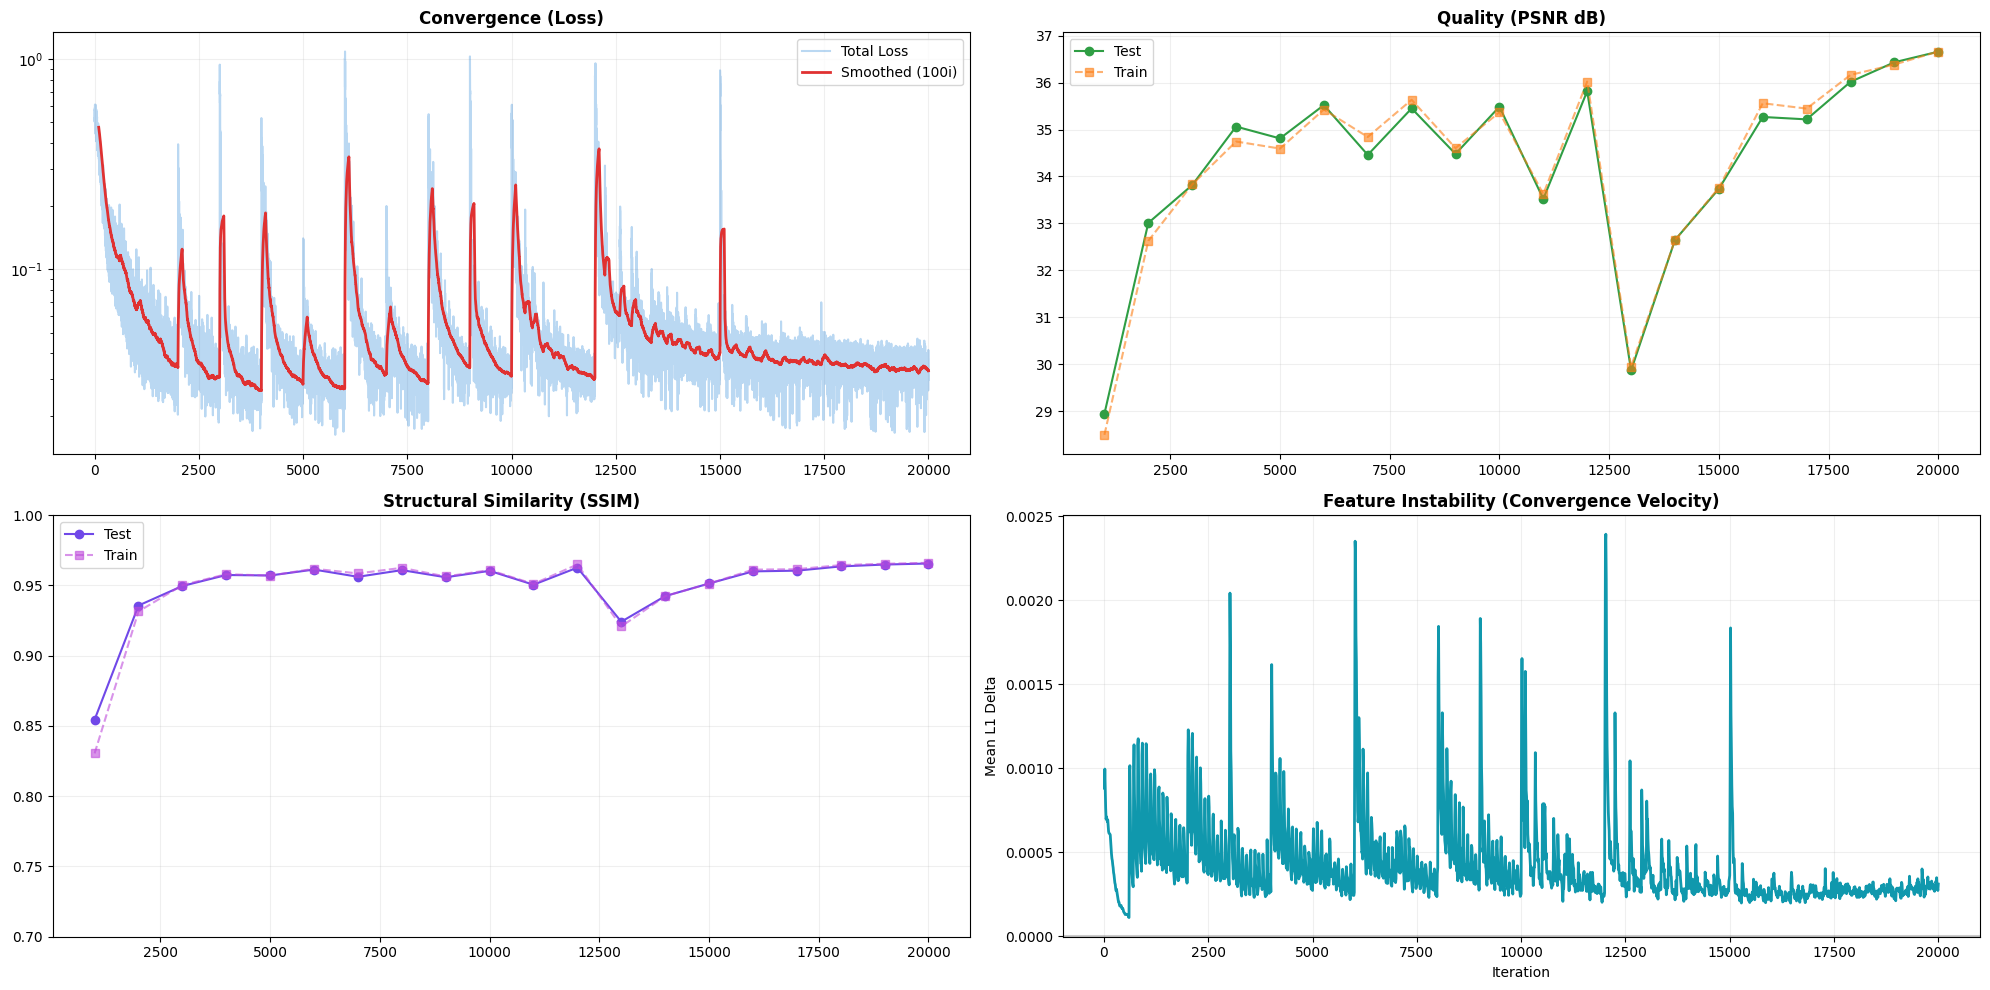

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

def plot_training_stats(json_path):
    # 1. Cargar los datos
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # 2. Extraer datos (Loss, PSNR, SSIM)
    loss_iters = [x['iter'] for x in data['loss']]
    loss_values = [x['value'] for x in data['loss']]
    
    psnr_test = data.get('psnr_test', [])
    psnr_train = data.get('psnr_train', [])
    ssim_test = data.get('ssim_test', [])
    ssim_train = data.get('ssim_train', [])
    instability = data.get('feature_instability', [])

    # 3. Crear la figura con tres subplots
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])
    
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1]) # Panel de texto para métricas finales

    # --- Subplot 1: Loss ---
    ax1.plot(loss_iters, loss_values, color='#1c7ed6', alpha=0.3, label='Total Loss')
    if len(loss_values) > 100:
        smoothed_loss = np.convolve(loss_values, np.ones(100)/100, mode='valid')
        ax1.plot(loss_iters[99:], smoothed_loss, color='#e03131', linewidth=2, label='Smoothed (100i)')
    ax1.set_title('Convergence (Loss)', fontweight='bold')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.2)
    ax1.legend()

    # --- Subplot 2: PSNR ---
    if psnr_test:
        ax2.plot([x['iter'] for x in psnr_test], [x['value'] for x in psnr_test], 'o-', color='#2f9e44', label='Test')
    if psnr_train:
        ax2.plot([x['iter'] for x in psnr_train], [x['value'] for x in psnr_train], 's--', color='#fd7e14', alpha=0.6, label='Train')
    ax2.set_title('Quality (PSNR dB)', fontweight='bold')
    ax2.grid(True, alpha=0.2)
    ax2.legend()

    # --- Subplot 3: SSIM ---
    if ssim_test:
        ax3.plot([x['iter'] for x in ssim_test], [x['value'] for x in ssim_test], 'o-', color='#7048e8', label='Test')
    if ssim_train:
        ax3.plot([x['iter'] for x in ssim_train], [x['value'] for x in ssim_train], 's--', color='#be4bdb', alpha=0.6, label='Train')
    ax3.set_title('Structural Similarity (SSIM)', fontweight='bold')
    ax3.set_ylim(0.7, 1.0) # El SSIM suele estar en este rango
    ax3.grid(True, alpha=0.2)
    ax3.legend()

    # --- Subplot 4: Métricas Finales (Semánticas) ---
    if instability:
        ax4.plot([x['iter'] for x in instability], [x['value'] for x in instability], color='#1098ad', linewidth=2)
    ax4.set_title('Feature Instability (Convergence Velocity)', fontweight='bold')
    ax4.set_ylabel('Mean L1 Delta')
    ax4.set_xlabel('Iteration')
    ax4.grid(True, alpha=0.2)
    # Una línea horizontal en 0 para visualizar la convergencia
    ax4.axhline(0, color='black', alpha=0.2)

    plt.tight_layout()
    plt.show()

# Uso
path = "/home/jsm15/opensplat3d/outputs/Replica/room0/20260421141638-3baec4c5/training_stats.json"
plot_training_stats(path)
